# ARTI 406 - Assignment 2: Data Quality Assessment & Preprocessing

**Instructor:** Dr. Alaa Alahmadi  
**Student:** Leen Mansour Alqahtani  
**ID:** 2230006599  

---

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

In this assignment, we apply practical preprocessing techniques on the **Air Quality UCI** dataset.

## Import Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 1. Load Dataset

In [69]:
pd.set_option("display.max_columns", None)

df = pd.read_csv('AirQualityUCI.csv', sep=';')
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
5,10/03/2004,23.00.00,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",NaN,NaN
6,11/03/2004,00.00.00,"1,2",1185.0,31.0,"3,6",690.0,62.0,1462.0,77.0,1333.0,733.0,"11,3","56,8","0,7603",NaN,NaN
7,11/03/2004,01.00.00,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702",NaN,NaN
8,11/03/2004,02.00.00,"0,9",1094.0,24.0,"2,3",609.0,45.0,1579.0,60.0,1276.0,620.0,"10,7","59,7","0,7648",NaN,NaN
9,11/03/2004,03.00.00,"0,6",1010.0,19.0,"1,7",561.0,-200.0,1705.0,-200.0,1235.0,501.0,"10,3","60,2","0,7517",NaN,NaN


## Task 1: Identify Data Quality Issues

Before cleaning, we inspect the dataset to identify any data quality problems.

In [70]:
# Check shape
print("Dataset shape:", df.shape)

Dataset shape: (9471, 17)


In [71]:
# Check data types
df.dtypes

,0
Date,object
Time,object
CO(GT),object
PT08.S1(CO),float64
NMHC(GT),float64
C6H6(GT),object
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64


In [72]:
# Check missing values
df.isna().sum()

,0
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
NMHC(GT),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114


In [91]:
# Check duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [74]:
# Fix decimal separator and convert to numeric
df = df.replace(',', '.', regex=True)

for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace -200 (invalid sensor readings) with NaN
df.replace(-200, np.nan, inplace=True)

# Drop unnamed empty columns
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

# Remove feature with 95% missing values
df = df.drop(columns=['NMHC(GT)'])

# Create Datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)
df = df.dropna(subset=['Datetime'])

print("Issues identified:")
print("- Date and Time stored as strings converted to Datetime")
print("- Sensor values of -200 represent invalid readings replaced with NaN")
print("- Unnamed columns 15 and 16 contain no useful data removed")
print("- Decimal values use comma separator instead of period fixed")
print("- 95% missing values in NMHC(GT), column removed")
print()
print("Missing values after fixing -200 values:")
print(df.isna().sum())

Issues identified:
- Date and Time stored as strings converted to Datetime
- Sensor values of -200 represent invalid readings replaced with NaN
- Unnamed columns 15 and 16 contain no useful data removed
- Decimal values use comma separator instead of period fixed
- 95% missing values in NMHC(GT), column removed

Missing values after fixing -200 values:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
Datetime            0
dtype: int64


## Task 2: Apply One Missing Value Strategy

We choose **mean imputation** for all numerical sensor columns.

**Reason:** The Air Quality dataset contains continuous sensor readings. Missing values were caused by sensor malfunction (marked as -200).


---


Mean imputation is appropriate here because:
- The data is continuous and approximately normally distributed for most features
- The proportion of missing values is moderate
- It preserves the dataset size without removing rows

In [75]:
# Define all numeric columns (excluding Date, Time, Datetime)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [76]:
# Apply mean imputation on all numeric columns
df_imputed = df.copy()
df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_imputed[numeric_cols].mean())

print("Missing values after mean imputation:")
print(df_imputed.isna().sum())

Missing values after mean imputation:
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
Datetime         0
dtype: int64


In [77]:
# Show sample rows after imputation
df_imputed[numeric_cols].head(10)

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.000000,1056.0,113.000000,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.000000,1174.0,92.000000,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.000000,1140.0,114.000000,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.000000,1092.0,122.000000,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.000000,1205.0,116.000000,1490.0,1110.0,11.2,59.6,0.7888
5,1.2,1197.0,4.7,750.0,89.000000,1337.0,96.000000,1393.0,949.0,11.2,59.2,0.7848
6,1.2,1185.0,3.6,690.0,62.000000,1462.0,77.000000,1333.0,733.0,11.3,56.8,0.7603
7,1.0,1136.0,3.3,672.0,62.000000,1453.0,76.000000,1333.0,730.0,10.7,60.0,0.7702
8,0.9,1094.0,2.3,609.0,45.000000,1579.0,60.000000,1276.0,620.0,10.7,59.7,0.7648
9,0.6,1010.0,1.7,561.0,246.896735,1705.0,113.091251,1235.0,501.0,10.3,60.2,0.7517


## Task 3: Detect and Handle Outliers Using IQR

We use the **Interquartile Range (IQR)** method to detect outliers in all numeric columns.

The IQR method defines outliers as values outside:  
**Q1 − 1.5×IQR** and **Q3 + 1.5×IQR**

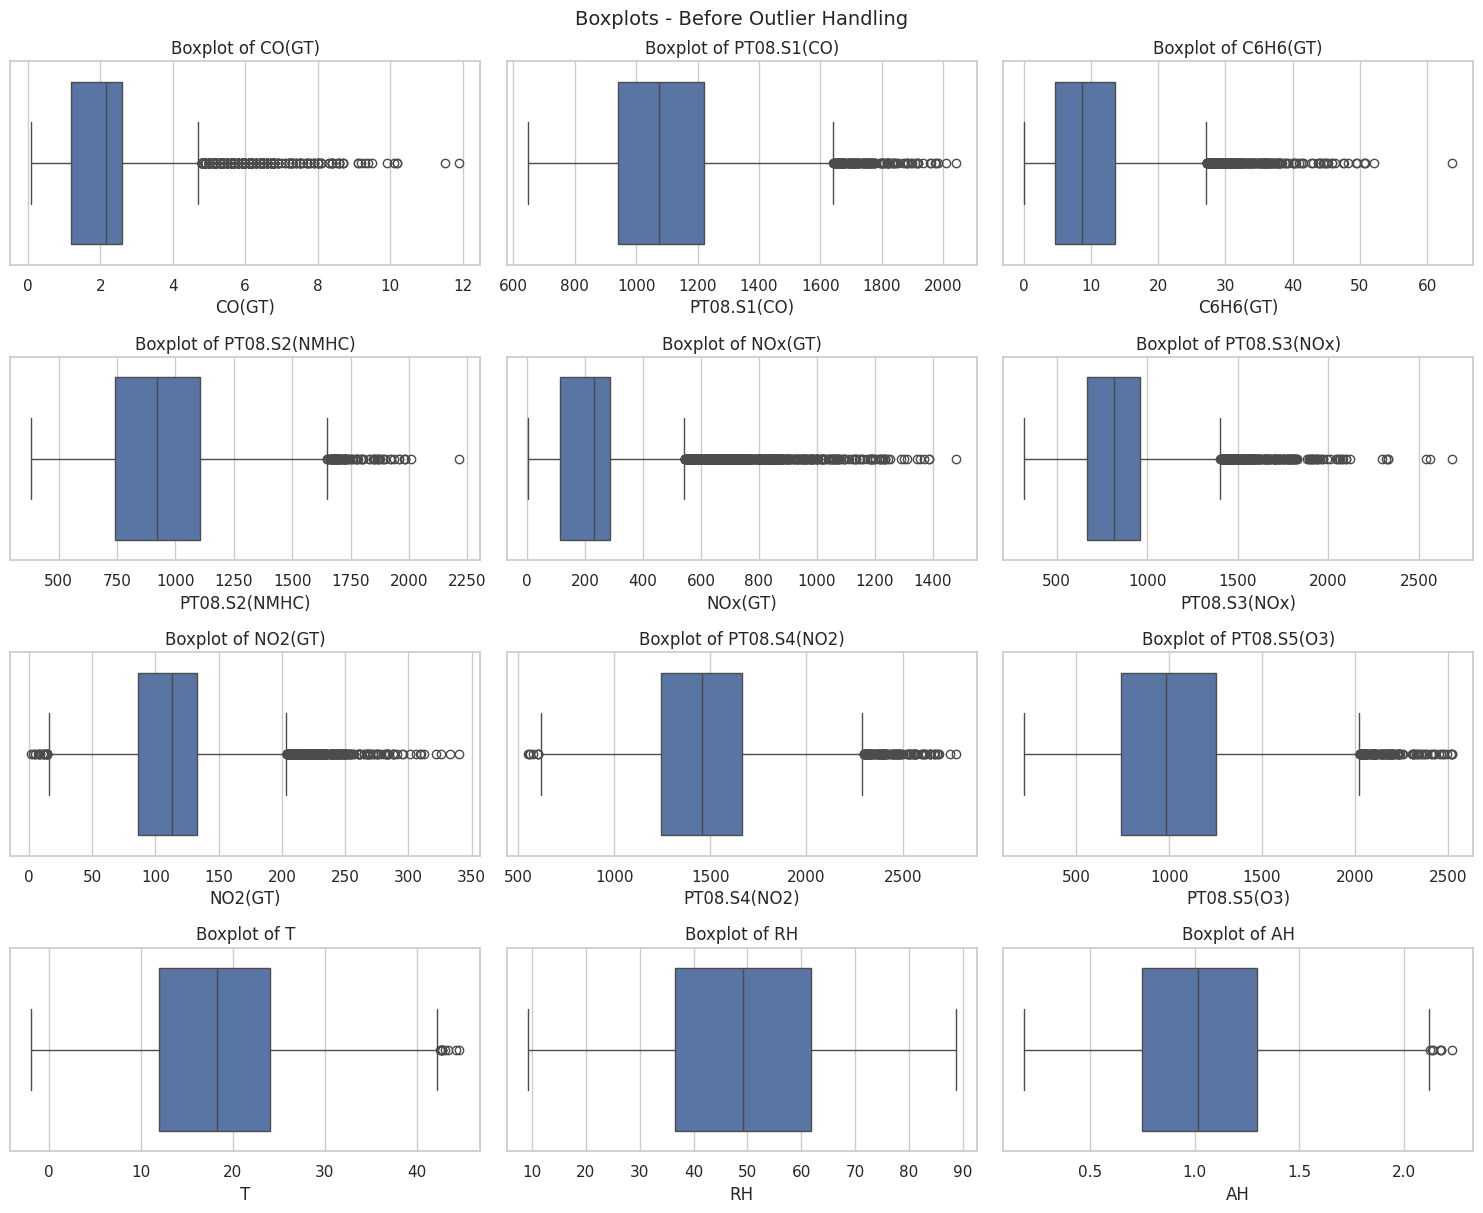

In [78]:
# Visualize outliers using boxplots for all numeric columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(15, n_rows * 3))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_imputed[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.suptitle("Boxplots - Before Outlier Handling", y=1.01, fontsize=14)
plt.show()

In [79]:
# Detect outliers in all numeric columns using IQR
outlier_summary = []

for col in numeric_cols:

    Q1 = df_imputed[col].quantile(0.25)
    Q3 = df_imputed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_imputed[col] < lower) | (df_imputed[col] > upper)).sum()
    outlier_summary.append({
        'Column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers Count': n_outliers
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

       Column      Q1     Q3    IQR  Lower Bound  Upper Bound  Outliers Count
       CO(GT)    1.20    2.6   1.40        -0.90         4.70             454
  PT08.S1(CO)  941.00 1221.0 280.00       521.00      1641.00             145
     C6H6(GT)    4.60   13.6   9.00        -8.90        27.10             286
PT08.S2(NMHC)  743.00 1105.0 362.00       200.00      1648.00              91
      NOx(GT)  112.00  284.0 172.00      -146.00       542.00             778
 PT08.S3(NOx)  666.00  960.0 294.00       225.00      1401.00             278
      NO2(GT)   86.00  133.0  47.00        15.50       203.50             380
 PT08.S4(NO2) 1242.00 1662.0 420.00       612.00      2292.00             131
  PT08.S5(O3)  742.00 1255.0 513.00       -27.50      2024.50             131
            T   12.00   24.1  12.10        -6.15        42.25              10
           RH   36.60   61.9  25.30        -1.35        99.85               0
           AH    0.75    1.3   0.55        -0.08         2.12   

In [80]:
# Handle outliers using IQR Capping

df_capped = df_imputed.copy()

for col in numeric_cols:

    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = np.where(
        df_capped[col] < lower,
        lower,
        df_capped[col]
    )

    df_capped[col] = np.where(
        df_capped[col] > upper,
        upper,
        df_capped[col]
    )

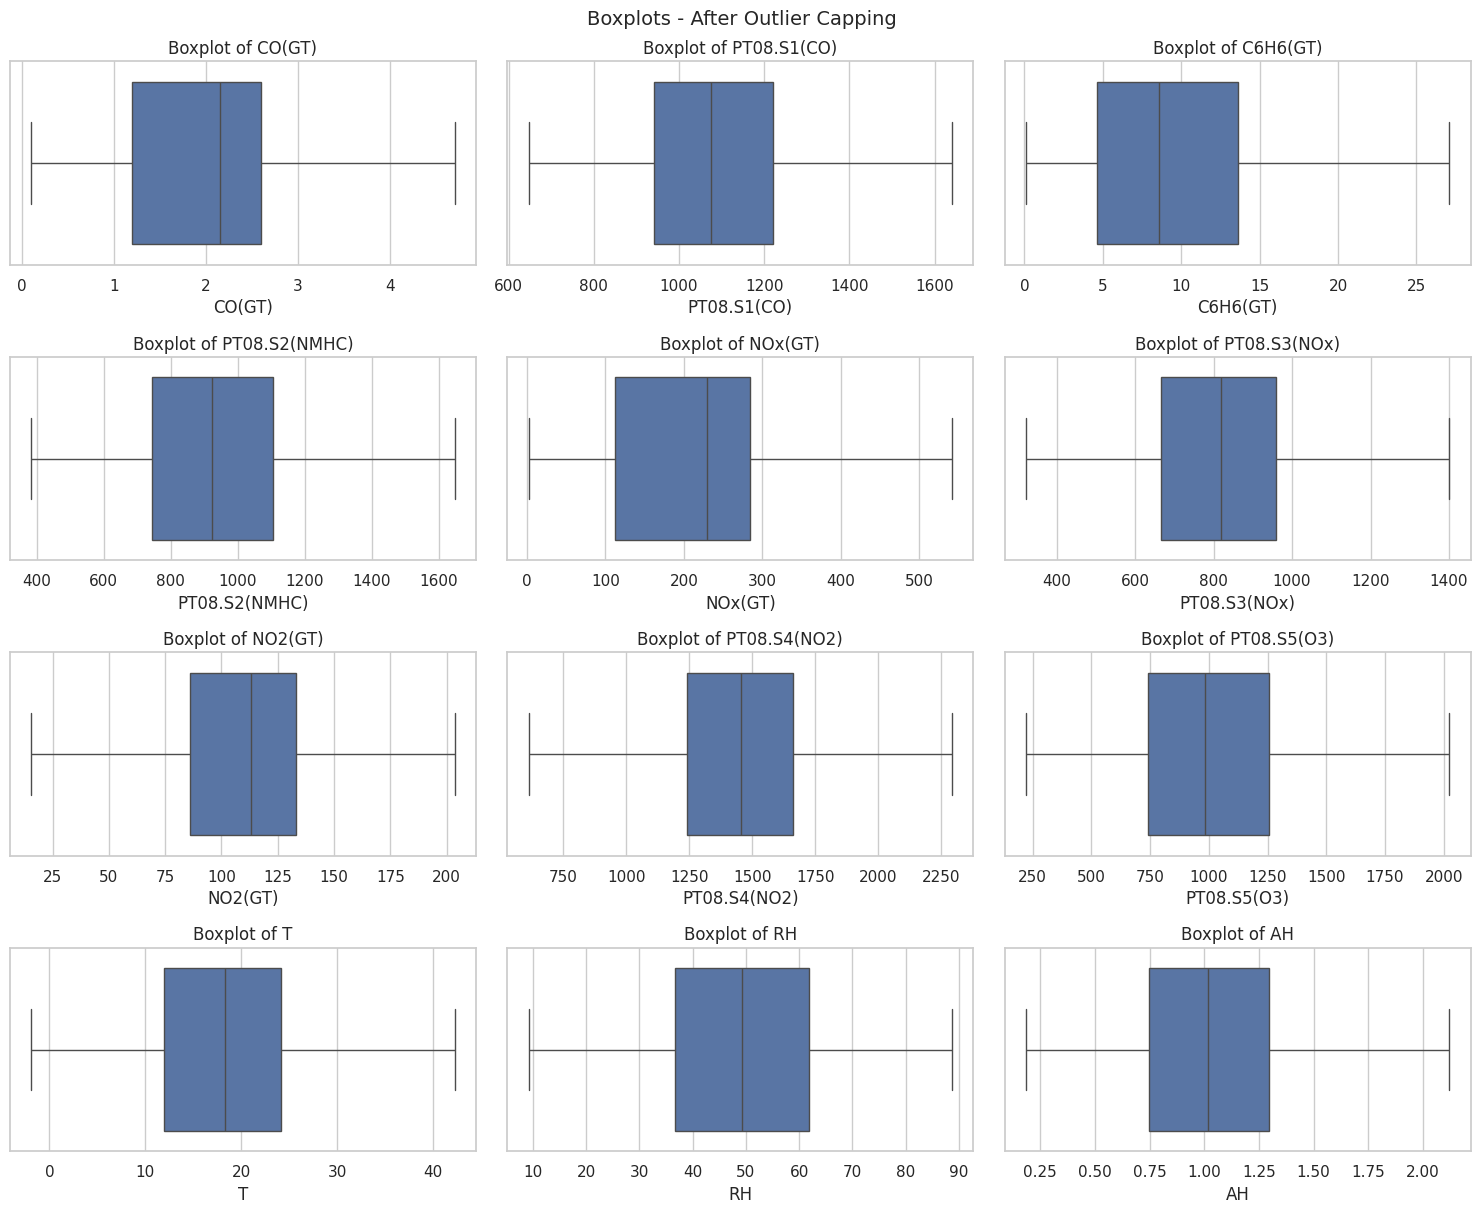

In [81]:
# Visualize after capping
plt.figure(figsize=(15, n_rows * 3))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_capped[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.suptitle("Boxplots - After Outlier Capping", y=1.01, fontsize=14)
plt.show()

## Task 4: Normalize Numerical Features

We normalize all numerical features using both **Min-Max** and **Z-score** normalization.

### 4.1 Min-Max Normalization

Scales all values to the range [0, 1] using: **(x − min) / (max − min)**

In [82]:
# Min-Max Normalization on all numeric columns
scaler_minmax = MinMaxScaler()
df_scaled = df_capped[numeric_cols].copy()
df_scaled[numeric_cols] = scaler_minmax.fit_transform(df_scaled)

print("After Min-Max Normalization:")
print(df_scaled.describe().round(4))

After Min-Max Normalization:
          CO(GT)  PT08.S1(CO)   C6H6(GT)  PT08.S2(NMHC)    NOx(GT)  \
count  9357.0000    9357.0000  9357.0000      9357.0000  9357.0000   
mean      0.4331       0.4538     0.3630         0.4388     0.4228   
std       0.2460       0.2088     0.2484         0.2040     0.2710   
min       0.0000       0.0000     0.0000         0.0000     0.0000   
25%       0.2391       0.2958     0.1667         0.2846     0.2037   
50%       0.4462       0.4306     0.3148         0.4269     0.4204   
75%       0.5435       0.5775     0.5000         0.5708     0.5222   
max       1.0000       1.0000     1.0000         1.0000     1.0000   

       PT08.S3(NOx)    NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)          T  \
count     9357.0000  9357.0000     9357.0000    9357.0000  9357.0000   
mean         0.4698     0.5135        0.5013       0.4434     0.4579   
std          0.2136     0.2179        0.1984       0.2131     0.1960   
min          0.0000     0.0000        0.0000       0

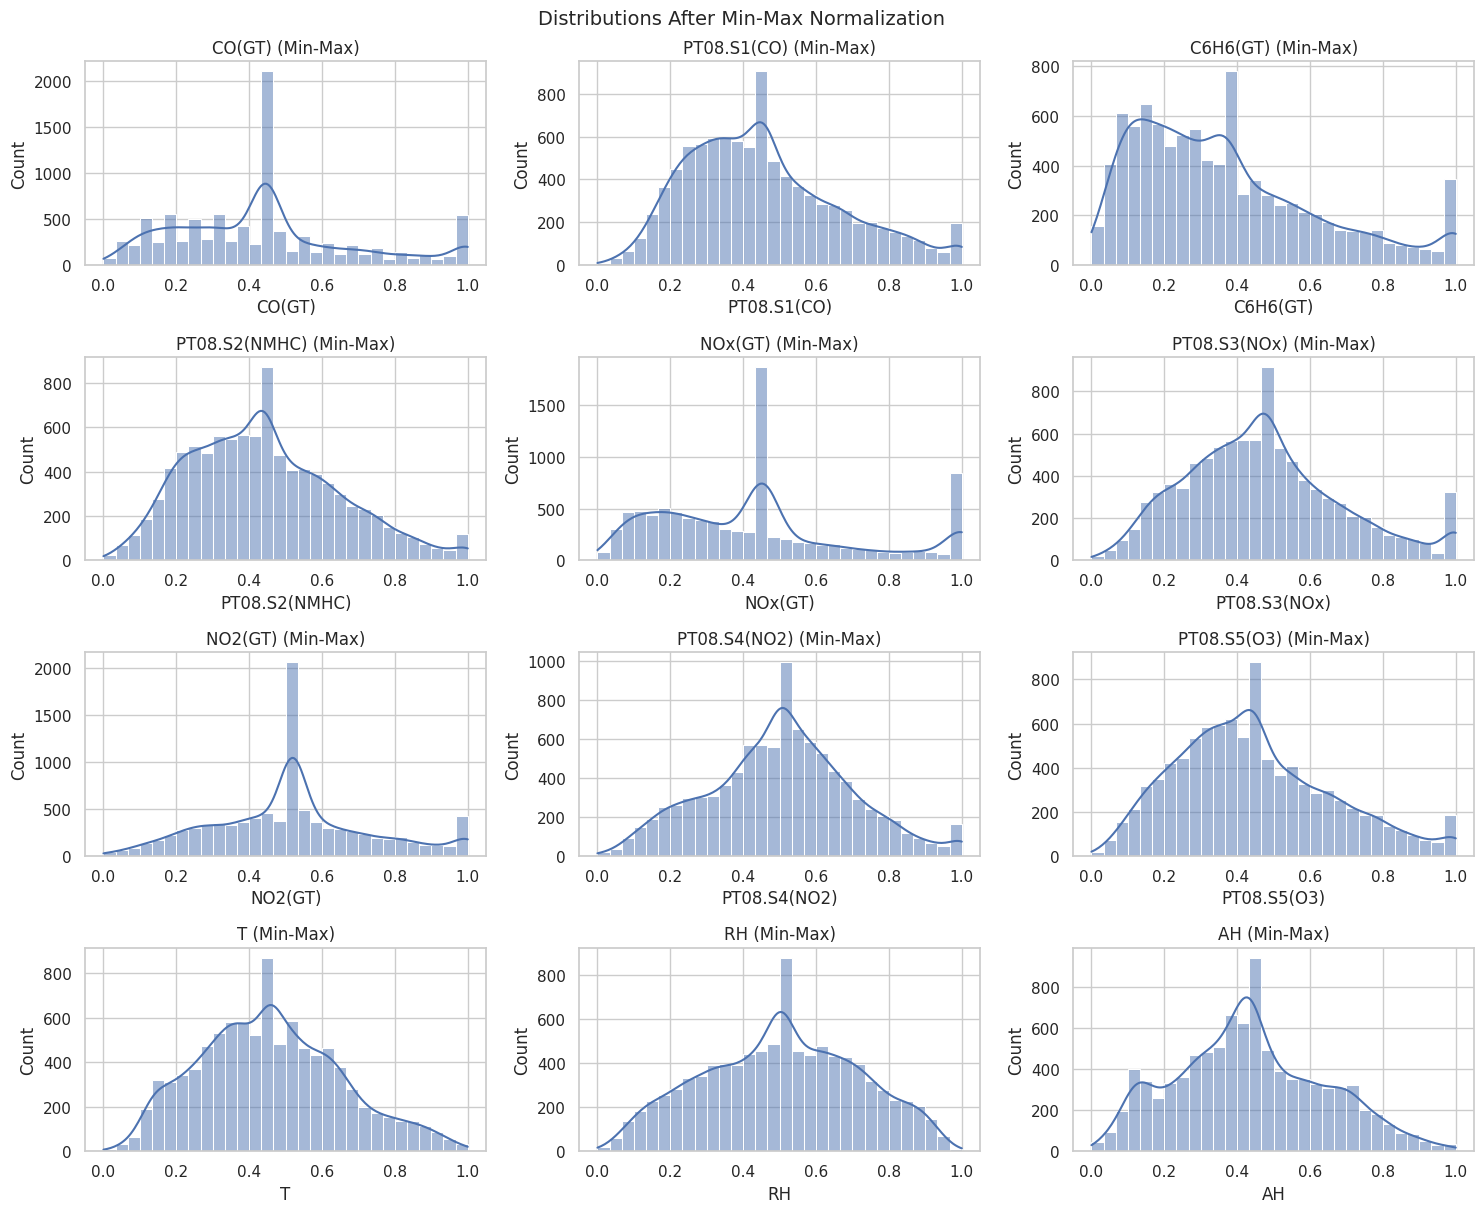

In [83]:
# Visualize distributions after Min-Max
plt.figure(figsize=(15, n_rows * 3))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_scaled[col], bins=30, kde=True)
    plt.title(f"{col} (Min-Max)")
plt.tight_layout()
plt.suptitle("Distributions After Min-Max Normalization", y=1.01, fontsize=14)
plt.show()

### 4.2 Z-Score Standardization

Transforms data so that **mean = 0** and **std = 1** using: **(x − mean) / std**

In [84]:
# Z-Score Standardization on all numeric columns
scaler_std = StandardScaler()
df_standardized = df_capped[numeric_cols].copy()
df_standardized[numeric_cols] = scaler_std.fit_transform(df_standardized)

print("After Z-Score Standardization:")
print(df_standardized.describe().round(4))

After Z-Score Standardization:
          CO(GT)  PT08.S1(CO)   C6H6(GT)  PT08.S2(NMHC)    NOx(GT)  \
count  9357.0000    9357.0000  9357.0000      9357.0000  9357.0000   
mean      0.0000      -0.0000     0.0000         0.0000    -0.0000   
std       1.0001       1.0001     1.0001         1.0001     1.0001   
min      -1.7610      -2.1734    -1.4611        -2.1510    -1.5601   
25%      -0.7887      -0.7569    -0.7902        -0.7558    -0.8084   
50%       0.0534      -0.1113    -0.1939        -0.0583    -0.0089   
75%       0.4487       0.5922     0.5516         0.6471     0.3670   
max       2.3049       2.6158     2.5642         2.7514     2.1300   

       PT08.S3(NOx)    NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)          T  \
count     9357.0000  9357.0000     9357.0000    9357.0000  9357.0000   
mean        -0.0000     0.0000       -0.0000      -0.0000     0.0000   
std          1.0001     1.0001        1.0001       1.0001     1.0001   
min         -2.1997    -2.3563       -2.5266      

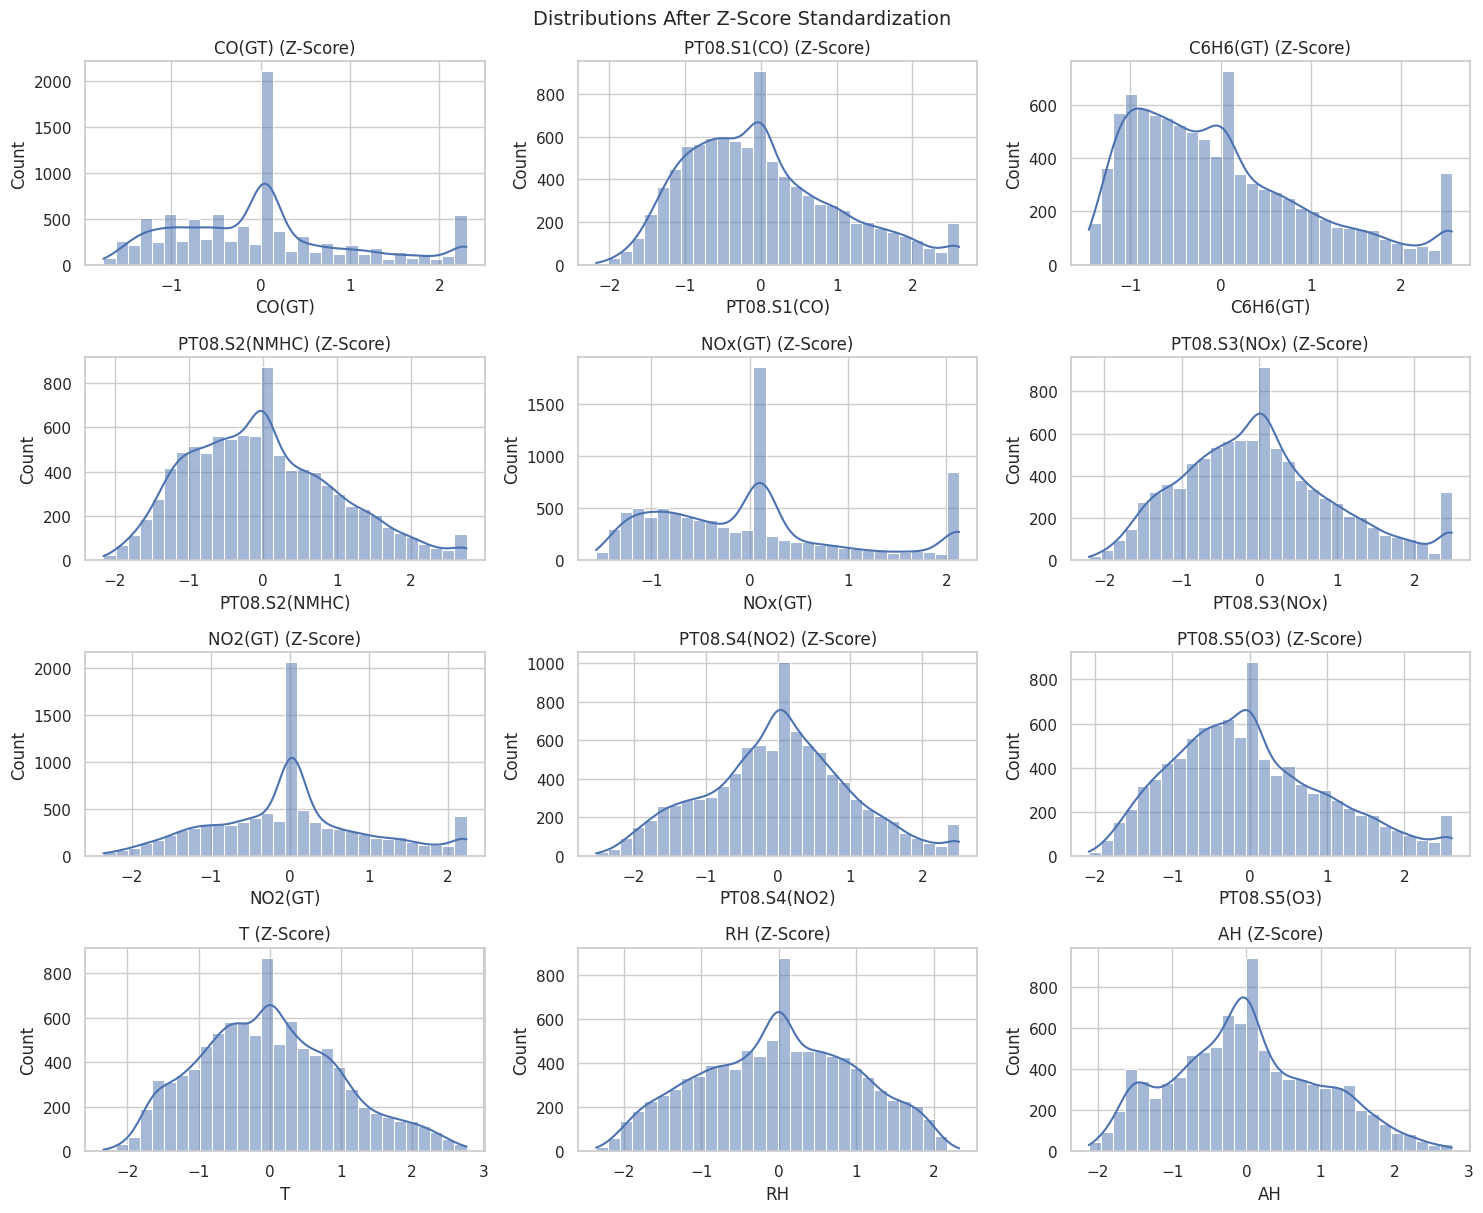

In [85]:
# Visualize distributions after Z-Score
plt.figure(figsize=(15, n_rows * 3))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_standardized[col], bins=30, kde=True)
    plt.title(f"{col} (Z-Score)")
plt.tight_layout()
plt.suptitle("Distributions After Z-Score Standardization", y=1.01, fontsize=14)
plt.show()

## Task 5: Apply PCA and Interpret Explained Variance

We apply **Principal Component Analysis (PCA)** on all standardized numeric features to reduce dimensionality.

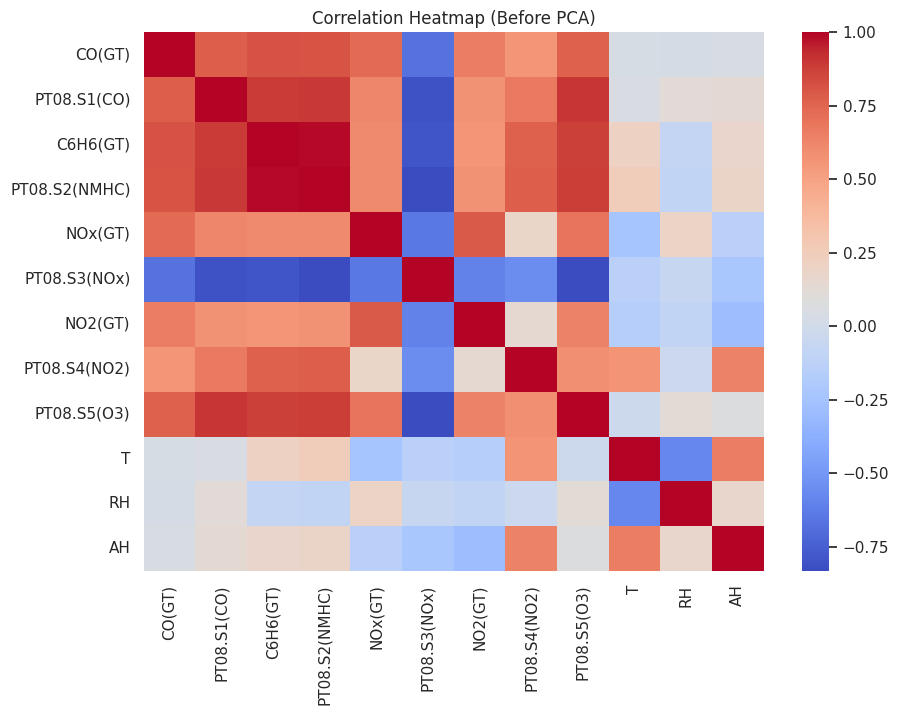

In [86]:
# Check correlation between all numeric features before PCA
plt.figure(figsize=(10, 7))
sns.heatmap(df_standardized.corr(), annot=False, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [87]:
# Apply PCA on all numeric columns
X = df_standardized[numeric_cols]
pca = PCA()
pca.fit(X)

print("Explained Variance Ratio per component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"\nCumulative variance with 2 components: {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")
print(f"Cumulative variance with 3 components: {sum(pca.explained_variance_ratio_[:3])*100:.2f}%")

Explained Variance Ratio per component:
  PC1: 55.89%
  PC2: 20.43%
  PC3: 11.20%
  PC4: 4.50%
  PC5: 2.98%
  PC6: 1.52%
  PC7: 1.21%
  PC8: 0.89%
  PC9: 0.73%
  PC10: 0.31%
  PC11: 0.29%
  PC12: 0.06%

Cumulative variance with 2 components: 76.32%
Cumulative variance with 3 components: 87.51%


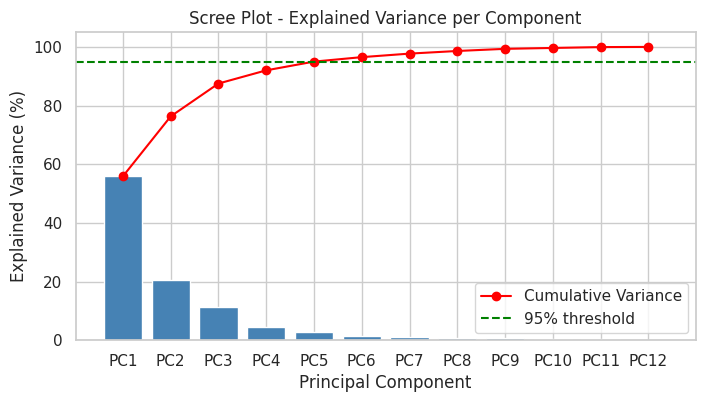

In [88]:
# Scree plot - variance explained by each component
plt.figure(figsize=(8, 4))
components = [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))]
plt.bar(components, pca.explained_variance_ratio_ * 100, color='steelblue')
plt.plot(components, np.cumsum(pca.explained_variance_ratio_) * 100,
         color='red', marker='o', label='Cumulative Variance')
plt.axhline(y=95, color='green', linestyle='--', label='95% threshold')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot - Explained Variance per Component")
plt.legend()
plt.show()

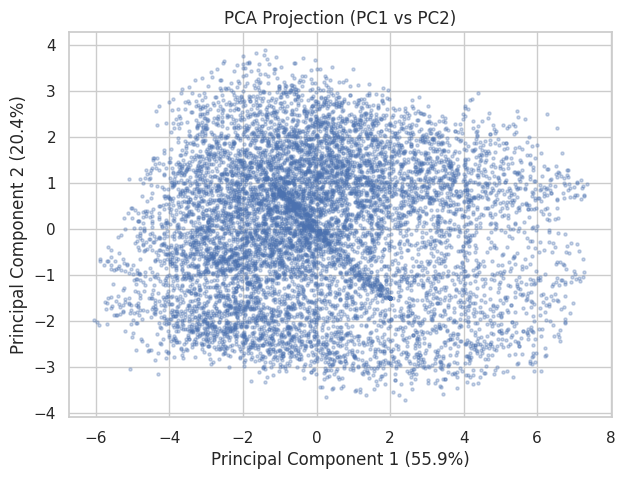

In [89]:
# Project data onto first 2 principal components for visualization
pca_2 = PCA(n_components=2)
principal_components = pca_2.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.3, s=5)
plt.title("PCA Projection (PC1 vs PC2)")
plt.xlabel(f"Principal Component 1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)")
plt.show()

### Interpretation

- The **Scree Plot** shows how much variance each principal component captures.
- The **red line** shows cumulative variance — we look for the point where it crosses 95%.
- Components with **higher bars** carry more information from the original features.
- Since the Air Quality dataset has many correlated sensor columns (e.g., multiple PT08 sensors measuring similar gases), PCA is effective here — a small number of components can capture most of the variance.
- This allows us to reduce dimensionality while retaining most of the useful information for modeling.

---


# Conclusion

The dataset was preprocessed by identifying data quality issues, handling missing values using mean imputation, detecting and treating outliers using the IQR method, applying Min-Max and Z-score normalization, and reducing dimensionality using PCA.

These preprocessing steps improved data quality and prepared the dataset for future machine learning applications.